# Project description

You work for the OilyGiant mining company. Your task is to find the best place for a new well..

You have data on oil samples from three regions. The data set for each region has 100,000 fields with measured oil quality and volume of reserves. Build a machine learning model that will help to pick the region with the highest profit margin. Analyze potential profits and risks using the Bootstrap technique.

Steps to choose the location:

- Look for the fields in the selected region, and determine the feature values for each field;
- Build a model and estimate the volume of reserves;
- Pick the field with the highest estimated values. The number of fields depends on the company's budget and the cost of development per well;
- The profit is equal to the total profit for the selected fields.

# 1. Data loading and preparation

Load the data and look into it

In [3]:
import pandas as pd

data_0 = pd.read_csv('datasets/geo_data_0.csv')
data_1 = pd.read_csv('datasets/geo_data_1.csv')
data_2 = pd.read_csv('datasets/geo_data_2.csv')

data_0.head()

,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647


Remove the extra column (id) and collect into a single list

In [6]:
data_all = [
    data_0.drop('id', axis=1),
    data_1.drop('id', axis=1),
    data_2.drop('id', axis=1),
]

Look at the target distribution

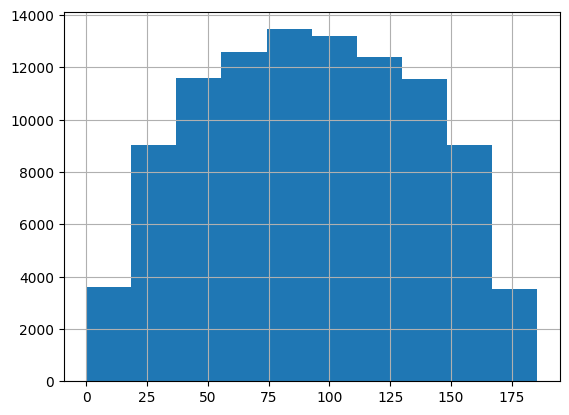

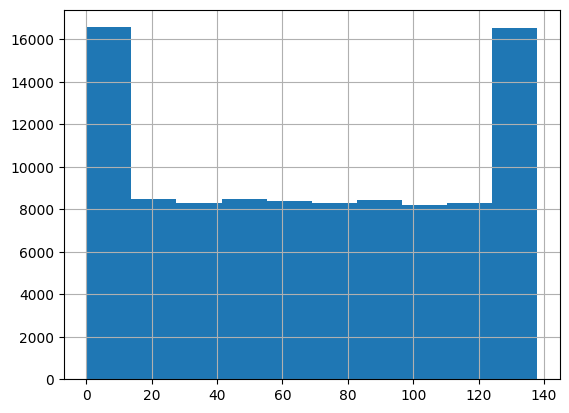

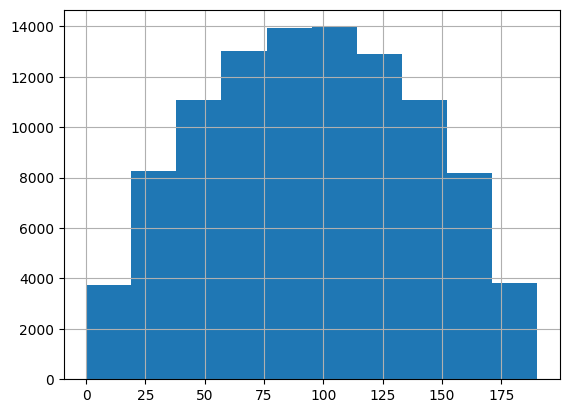

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

for data in data_all:
    plt.figure()
    data['product'].hist()

# 2. Model training and testing

In [7]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

state = np.random.RandomState(12345)

samples_target = []
samples_predictions = []
for region in range(len(data_all)):
    data = data_all[region]
    features = data.drop('product', axis=1)
    target = data['product']
    
    features_train, features_valid, target_train, target_valid = train_test_split(
        features, target, test_size=0.25, random_state=state)
    
    model = LinearRegression()
    model.fit(features_train, target_train)
    predictions = model.predict(features_valid)
    
    samples_target.append(target_valid.reset_index(drop=True))
    samples_predictions.append(pd.Series(predictions))
    
    mean_product = target.mean()
    model_rmse = mean_squared_error(target_valid, predictions)**0.5
    
    print("-- Region", region, "--")
    print("mean product amount =", mean_product)
    print("Model RMSE:", model_rmse)
    print()

-- Region 0 --
mean product amount = 92.50000000000001
Model RMSE: 37.5794217150813

-- Region 1 --
mean product amount = 68.82500000000002
Model RMSE: 0.8897367737680646

-- Region 2 --
mean product amount = 95.00000000000004
Model RMSE: 39.958042459521614



**Finding:** Judging by the mean concentration of the product, the most profitable is Region 2. But it has the highest model error, so further analysis is needed.

# 3. Preparation for profit calculationи

In [8]:
#All amounts are divided by 100 for easier operations

BUDGET = 1000000
COST_PER_POINT = 5000
POINTS_PER_BUDGET = BUDGET // COST_PER_POINT

PRODUCT_PRICE = 45

def profit(target, predictions):
    predictions_sorted = predictions.sort_values(ascending=False)
    selected_points = target[predictions_sorted.index][:POINTS_PER_BUDGET]
    product = selected_points.sum()
    revenue = product * PRODUCT_PRICE
    cost = BUDGET
    return revenue - cost

In [9]:
COST_PER_POINT = BUDGET / POINTS_PER_BUDGET
zero_profit_product = COST_PER_POINT / PRODUCT_PRICE
print("Amount of product for 0 profit:", zero_profit_product)

Amount of product for 0 profit: 111.11111111111111


**Finding:** In all regions, product concentration is too low to select points randomly..

In [12]:
samples_target[0].sort_values()

6510       0.004022
1370       0.021781
19276      0.024830
344        0.045335
8910       0.062346
            ...    
21256    185.260807
13712    185.261773
18422    185.293551
13810    185.297021
4768     185.315412
Name: product, Length: 25000, dtype: float64

In [13]:
samples_predictions[0].sort_values()

20881     -9.367846
14503      4.980987
21875      6.569477
9078       8.798531
23129     10.209351
            ...    
23388    173.299686
11584    175.658429
10015    175.850623
219      176.252213
9317     180.180713
Length: 25000, dtype: float64

# 4. Calculation of profit and risks

In [21]:
SAMPLE_SIZE = 500
BOOTSTRAP_SIZE = 1000

for region in range(3):
    target = samples_target[region]
    predictions = samples_predictions[region]
    
    profit_values = []
    for i in range(BOOTSTRAP_SIZE):
        target_sample = target.sample(SAMPLE_SIZE, replace=True, random_state=state)
        predictions_sample = predictions[target_sample.index]
        profit_values.append(profit(target_sample, predictions_sample))
    profit_values = pd.Series(profit_values)
        
    mean_profit = profit_values.mean()
    confidence_interval = (profit_values.quantile(0.025), profit_values.quantile(0.975))
    negative_profit_chance = (profit_values < 0).mean()
    
    print("-- Region", region, "--")
    print("Mean profit =", mean_profit)
    print("95% confidence interval:", confidence_interval)
    print("Risk of losses =", negative_profit_chance * 100, "%")
    print()

-- Region 0 --
Mean profit = 42389.7237916905
95% confidence interval: (-7618.781389036387, 95784.65319517831)
Risk of losses = 4.8 %

-- Region 1 --
Mean profit = 51325.66989172609
95% confidence interval: (10806.689523396148, 92857.44392324961)
Risk of losses = 0.6 %

-- Region 2 --
Mean profit = 38112.035957590095
95% confidence interval: (-14280.063008786794, 89338.05657504003)
Risk of losses = 7.3999999999999995 %



**Finding:** Region 1 should be suggested for development: it has the highest estimated profit and the risk of losses is less than 2.5%